### **Latent Space Analysis and Visualisation**

In [20]:
import sys
from typing import Any, NamedTuple

from tqdm import tqdm
import torch
from torch.types import Tensor


class LatentVector(NamedTuple):
    """Latent vector container."""
    vals: Tensor
    lbls: Tensor


def get_size(obj: object, default: Any = -1) -> int:
    """Computes how much memory storage is being used by input obj in [bytes]."""
    return sys.getsizeof(obj, default=default)

In [21]:
#BASEPATH: str = '/home/edoardo/Desktop/MockDataForDMs'
BASEPATH: str = '/mnt/d/MockDataForDMs'

latent_dmap: dict[int, LatentVector] = torch.load(f'{BASEPATH}/latentSpaceContainer.pt', weights_only=False)

print(
    f'Latent Space dmap size: {get_size(latent_dmap)} bytes\n'
    f'Number of epochs registered: {len(latent_dmap)}\n'
    f'Embedded data size: vector = {latent_dmap[0].vals.shape}, lbls = {latent_dmap[0].lbls.shape}\n'
)

# NOTE:
#   - a tensor of shape [E, B, C, H, W] occupies less memory than the latent dict map
#   - when saved though, the 5D tensor occupies x2 space (dmap: ~13.7MB, tensor: ~27  MB)
#   - this has been tested on 5 epochs (TODO: test if for larger # of epochs is the same)

Latent Space dmap size: 224 bytes
Number of epochs registered: 5
Embedded data size: vector = torch.Size([800, 8, 15, 15]), lbls = torch.Size([800])



In [22]:
from itertools import islice
import numpy as np
from numpy.typing import NDArray


def manage_embedded_data(latent_dmap: dict[int, LatentVector]) -> dict[int, tuple[NDArray, NDArray]]:
    """
    Takes the data in the latent dmap and for each epoch flattens the respective
    embedded vector of shape [B, C, H, W] to a tensor [B, C x H x W], finally
    converting it to a numpy array.
    """
    # use `islice` bc `latent_dmap` could be very large (epochs
    # number + respective tensors with all the latent vectors)
    flattened_dmap: dict[int, NDArray] = {
        epoch: (emb.vals.flatten(1, -1).numpy(), emb.lbls.numpy())
        for epoch, emb in islice(latent_dmap.items(), len(latent_dmap))
    }
    return flattened_dmap

In [23]:
EPOCH: int = 0

np_emb: dict[int, NDArray] = manage_embedded_data(latent_dmap)

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]

In [24]:
import umap

N_NEIGHBORS: int = 15
N_COMPONENTS: int = 2
MIN_DIST: float = 0.1
METRIC: str = 'euclidean'
METRIC_KWDS : dict[str, Any] = {}


reducer = umap.UMAP(
    n_neighbors=N_NEIGHBORS,
    n_components=N_COMPONENTS,
    min_dist=MIN_DIST,
    metric=METRIC,
    metric_kwds=METRIC_KWDS,
)

In [25]:
# the data on which the fit is performed should be processed a bit:
#   - remove NaNs (usually)
#   - avoid different data scales (convert features into z-scores --# of std from mean-- for comparability)

embedding = reducer.fit_transform(epoch_latent_vector)
embedding.shape

(800, 2)

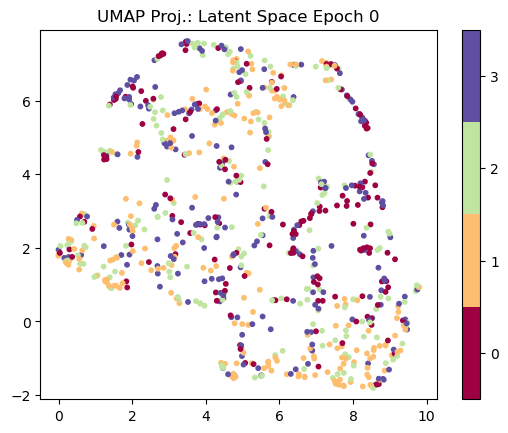

In [26]:
import matplotlib.pyplot as plt


plt.scatter(embedding[:, 0], embedding[:, 1], c=epoch_lbls, cmap='Spectral', s=10)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(5)-0.5).set_ticks(np.arange(4))
plt.title(f'UMAP Proj.: Latent Space Epoch {EPOCH}', fontsize=12)
plt.show()

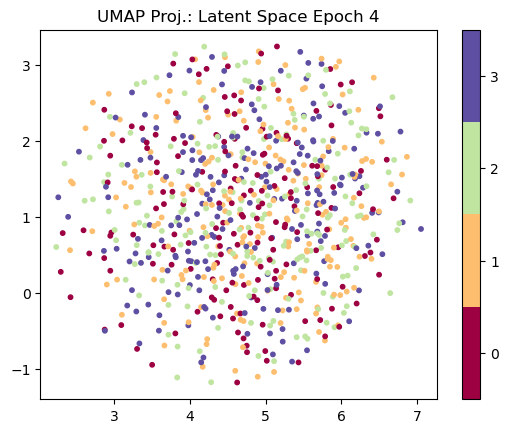

In [27]:
EPOCH: int = 4

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]
embedding = reducer.fit_transform(epoch_latent_vector)

plt.scatter(embedding[:, 0], embedding[:, 1], c=epoch_lbls, cmap='Spectral', s=10)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(5)-0.5).set_ticks(np.arange(4))
plt.title(f'UMAP Proj.: Latent Space Epoch {EPOCH}', fontsize=12)
plt.show()

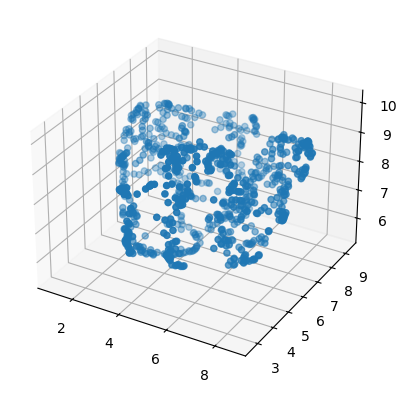

In [29]:
def draw_umap(data, n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    u = fit.fit_transform(data)
    fig = plt.figure()
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], u[:,1])
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(u[:,0], u[:,1], u[:,2], s=20)
    plt.title(title, fontsize=12)
    plt.show()
    return


EPOCH: int = 0
epoch_latent_vector, epoch_lbls = np_emb[EPOCH]

draw_umap(epoch_latent_vector, n_components=3)

In [ ]:
import umap.plot as upt

upt.points(embedding)

/home/starfloyd/anaconda3/envs/spark/lib/python3.13/site-packages/umap/plot.py:20: UserWarning: The umap.plot package requires extra plotting libraries to be installed.
    You can install these via pip using

    pip install umap-learn[plot]

    or via conda using

     conda install pandas matplotlib datashader bokeh holoviews colorcet scikit-image
    
  warn(


ImportError: umap.plot requires pandas matplotlib datashader bokeh holoviews scikit-image and colorcet to be installed